# Qlib 回测

本 Notebook 演示如何将动量策略信号接入 **Qlib 回测引擎**，相比 `03_simple_backtest.ipynb` 的简单乘法模拟，Qlib 回测额外处理：

- **T+1**：当日买入次日才能卖出（A 股规则）
- **交易成本**：开仓万五、平仓千一点五、最低 5 元
- **涨跌停限制**：单日振幅超过 9.5% 时无法成交
- **基准对比**：自动生成超额收益曲线

**前置条件**：需先运行过 `03_simple_backtest.ipynb`（因子已写入 `factors.daily_factors`），
且 Qlib 数据已初始化（`docker compose exec app bash scripts/init_qlib_data.sh`）。

In [1]:
import os
import sys
sys.path.insert(0, '/app')

import pandas as pd
import polars as pl
from loguru import logger

SYMBOL   = '000001.SZ'
START    = '2023-01-01'
# END is set to one trading day before the last calendar date.
# TopkDropoutStrategy looks up the next day's price on each step;
# using the last calendar date causes an off-by-one IndexError.
END      = '2024-12-30'
ACCOUNT  = 1_000_000
BENCHMARK = None

## 1. 生成动量策略信号

与 `03_simple_backtest.ipynb` 相同：从 TimescaleDB 读取因子 → 运行 `MomentumStrategy`。

In [2]:
from app.strategy.momentum import MomentumStrategy

df_factors = pl.read_database_uri(
    query=f"""
        SELECT time, symbol, factor_name, factor_value
        FROM factors.daily_factors
        WHERE symbol = '{SYMBOL}'
          AND time >= '{START}'
        ORDER BY time, factor_name
    """,
    uri=os.environ['DATABASE_URL'],
)

strategy = MomentumStrategy(rsi_overbought=70, rsi_oversold=30)
df_signals = strategy.generate_signals(df_factors, universe=[SYMBOL])

print(f'信号记录数: {len(df_signals)}')
print(f'非零信号数: {df_signals.filter(pl.col("signal") != 0).height}')
df_signals.head()

2026-03-17 15:03:10.980 | INFO     | app.strategy.momentum:generate_signals:89 - [momentum_v1] 生成信号 425 条，买入=4，卖出=7


信号记录数: 425
非零信号数: 11


time,symbol,strategy,signal,score,metadata
"datetime[μs, UTC]",str,str,i32,f64,str
2023-04-03 00:00:00 UTC,"""000001.SZ""","""momentum_v1""",0,-0.964,null
2023-04-04 00:00:00 UTC,"""000001.SZ""","""momentum_v1""",0,-0.997333,null
2023-04-06 00:00:00 UTC,"""000001.SZ""","""momentum_v1""",0,-1.015833,null
2023-04-07 00:00:00 UTC,"""000001.SZ""","""momentum_v1""",0,-1.013833,null
2023-04-10 00:00:00 UTC,"""000001.SZ""","""momentum_v1""",0,-1.0045,null


## 2. 转换为 Qlib 预测格式

Qlib 策略的 `signal` 参数需要一个 `pd.Series`，索引为 `MultiIndex(datetime, instrument)`，值为连续分数（即我们的 `score = ma20 - ma60`）。

**股票代码格式说明**：Qlib CN 数据的 instrument 代码格式取决于 `init_qlib_data.sh` 的初始化方式。
常见格式为 `SZ000001`（无点号，交易所前缀），若与本地 qlib_data 不匹配需调整 `QLIB_INSTRUMENT`。

In [3]:
# Qlib 中 A 股代码格式：'000001.SZ' → 'SZ000001'
# 若 qlib_data 使用其他格式（如 '000001'），请修改此转换
def to_qlib_instrument(symbol: str) -> str:
    code, exchange = symbol.split('.')
    return f'{exchange}{code}'

QLIB_INSTRUMENT = to_qlib_instrument(SYMBOL)  # 'SZ000001'
print(f'Qlib instrument code: {QLIB_INSTRUMENT}')

# 构造 pred: pd.Series，MultiIndex(datetime, instrument)，值为 score
pred = (
    df_signals
    .select(['time', 'symbol', 'score'])
    # 去除时区，Qlib 内部使用 tz-naive datetime
    .with_columns(pl.col('time').dt.replace_time_zone(None))
    .with_columns(pl.col('symbol').map_elements(to_qlib_instrument, return_dtype=pl.Utf8))
    # score=NaN 的行（信号为 0）填 0，避免 Qlib 忽略这些日期
    .with_columns(pl.col('score').fill_nan(0.0))
    .to_pandas()
)
pred['time'] = pd.to_datetime(pred['time'])
pred = pred.set_index(['time', 'symbol'])['score']
pred.index.names = ['datetime', 'instrument']

print(f'pred 长度: {len(pred)}')
pred.tail()

Qlib instrument code: SZ000001
pred 长度: 425


datetime    instrument
2024-12-25  SZ000001     -0.043000
2024-12-26  SZ000001     -0.028833
2024-12-27  SZ000001     -0.013167
2024-12-30  SZ000001      0.019167
2024-12-31  SZ000001      0.049333
Name: score, dtype: float64

## 3. 初始化 Qlib

In [4]:
from app.utils.qlib_helper import init_qlib
init_qlib(region='cn')

[2660:MainThread](2026-03-17 15:03:12,331) INFO - qlib.Initialization - [config.py:452] - default_conf: client.
[2660:MainThread](2026-03-17 15:03:13,126) INFO - qlib.Initialization - [__init__.py:75] - qlib successfully initialized based on client settings.
[2660:MainThread](2026-03-17 15:03:13,127) INFO - qlib.Initialization - [__init__.py:77] - data_path={'__DEFAULT_FREQ': PosixPath('/app/qlib_data')}
2026-03-17 15:03:13.128 | INFO     | app.utils.qlib_helper:init_qlib:35 - Qlib 初始化完成: uri=/app/qlib_data, region=cn


## 4. 运行 Qlib 回测

使用 `TopkDropoutStrategy(topk=1)`：在 `pred` 中分数最高的股票建仓，分数转负时清仓。

单股场景下等价于：`score > 0` → 持有，`score <= 0` → 空仓。

In [5]:
import warnings
from qlib.backtest import backtest
from qlib.backtest.executor import SimulatorExecutor
from qlib.backtest import report as _qlib_report
from qlib.contrib.strategy import TopkDropoutStrategy

# ── Qlib bug workaround ───────────────────────────────────────
# When benchmark=None, Qlib passes {} to Account instead of None,
# causing _cal_benchmark({}) to fall back to CSI300_BENCH default.
_orig_cal_benchmark = _qlib_report.PortfolioMetrics._cal_benchmark

@staticmethod
def _patched_cal_benchmark(benchmark_config, freq):
    if not benchmark_config:
        return None
    return _orig_cal_benchmark(benchmark_config, freq)

_qlib_report.PortfolioMetrics._cal_benchmark = _patched_cal_benchmark
# ─────────────────────────────────────────────────────────────

executor = SimulatorExecutor(
    time_per_step='day',
    generate_portfolio_metrics=True,
)

strategy_obj = TopkDropoutStrategy(
    signal=pred,
    topk=1,
    n_drop=1,
    hold_thresh=1,
)

exchange_kwargs = {
    'limit_threshold': 0.095,
    'deal_price': 'close',
    'open_cost': 0.0005,
    'close_cost': 0.0015,
    'min_cost': 5,
}

with warnings.catch_warnings():
    warnings.filterwarnings('ignore', message='Mean of empty slice', category=RuntimeWarning)
    portfolio_metric_dict, indicator_dict = backtest(
        strategy=strategy_obj,
        executor=executor,
        start_time=START,
        end_time=END,
        account=ACCOUNT,
        benchmark=BENCHMARK,
        exchange_kwargs=exchange_kwargs,
    )

print('回测完成')

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
[2660:MainThread](2026-03-17 15:03:13,405) WARNING - qlib.data - [data.py:665] - load calendar error: freq=day, future=True; return current calendar!
[2660:MainThread](2026-03-17 15:03:13,405) WARNING - qlib.data - [data.py:668] - You can get future calendar by referring to the following document: https://github.com/microsoft/qlib/blob/main/scripts/data_collector/contrib/README.md
[2660:MainThread](2026-03-17 15:03:13,408) WARNING - qlib.BaseExecutor - [executor.py:121] - `common_infra` is not s

backtest loop:   0%|          | 0/483 [00:00<?, ?it/s]

回测完成


## 5. 绩效分析

In [6]:
from qlib.contrib.evaluate import risk_analysis

report_df, positions_df = portfolio_metric_dict.get('1day', (None, None))

if report_df is not None:
    print('=== 策略绝对收益分析 ===')
    print(risk_analysis(report_df['return']))
    print(f'\nreport_df 列: {report_df.columns.tolist()}')
else:
    print('未获取到 report_df，请检查 Qlib 数据是否已初始化')

=== 策略绝对收益分析 ===
                       risk
mean               0.000365
std                0.011585
annualized_return  0.086837
information_ratio  0.485861
max_drawdown      -0.213711

report_df 列: ['account', 'return', 'total_turnover', 'turnover', 'total_cost', 'cost', 'value', 'cash', 'bench']


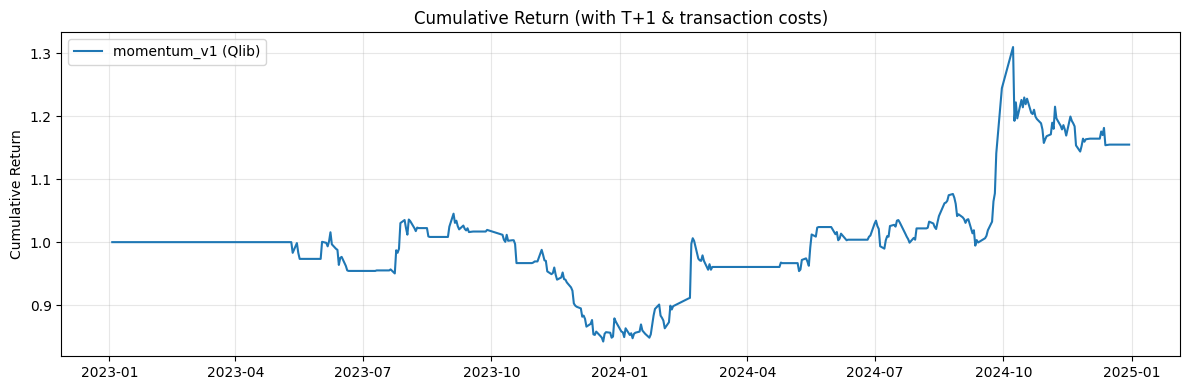

In [7]:
import matplotlib.pyplot as plt

if report_df is not None:
    fig, ax = plt.subplots(figsize=(12, 4))
    cum_strategy = (1 + report_df['return']).cumprod()
    ax.plot(cum_strategy.index, cum_strategy.values, label='momentum_v1 (Qlib)')
    ax.set_title('Cumulative Return (with T+1 & transaction costs)')
    ax.set_ylabel('Cumulative Return')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 6. 与简单回测对比

对比 `03_simple_backtest.ipynb` 的结果，观察加入 T+1 和交易成本后绩效的变化。

In [8]:
from app.backtest.metrics import compute_metrics

# 简单回测（复用 03 的逻辑）
df_price = pl.read_database_uri(
    query=f"""
        SELECT time, symbol, pct_change
        FROM market.daily
        WHERE symbol = '{SYMBOL}'
          AND time >= '{START}'
        ORDER BY time
    """,
    uri=os.environ['DATABASE_URL'],
)

df_bt = (
    df_signals
    .select(['time', 'symbol', 'signal'])
    .join(df_price, on=['time', 'symbol'])
    .sort('time')
    .with_columns(
        (pl.col('signal').shift(1) * pl.col('pct_change') / 100).alias('strategy_ret')
    )
    .drop_nulls('strategy_ret')
)
simple_metrics = compute_metrics(df_bt['strategy_ret'], freq='daily')

# Qlib 回测指标（若可用）
if report_df is not None:
    qlib_ret = report_df['return']
    qlib_metrics = compute_metrics(pl.Series(qlib_ret.values), freq='daily')
else:
    qlib_metrics = {k: None for k in simple_metrics}

print(f'{'指标':20s}  {'简单回测':>12s}  {'Qlib回测(T+1+成本)':>20s}')
print('-' * 58)
for k in simple_metrics:
    sv = simple_metrics[k]
    qv = qlib_metrics.get(k)
    qv_str = f'{qv:>20.4f}' if qv is not None else f'{"N/A":>20s}'
    print(f'{k:20s}  {sv:>12.4f}  {qv_str}')

SyntaxError: f-string: expecting '}' (3051440762.py, line 34)